In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
df = pd.read_csv("C:/Users/ADHITHYA/Downloads/archive (1)/Internship_Selection_Dataset.csv")

print(df.head())

   student_id  CGPA  skills_score  projects_count  internships_done  \
0           1  6.87             7               0                 0   
1           2  9.75             4               4                 2   
2           3  8.66             2               1                 1   
3           4  7.99             5               4                 2   
4           5  5.78             3               2                 2   

   communication_score  aptitude_score  coding_test_score  resume_score  \
0                    4               3                  2             7   
1                    3               3                  6             1   
2                    2               1                  4             6   
3                    8               8                 10             8   
4                    4               9                  1             7   

  extracurricular  ... hackathons_participated  certifications_count  \
0             Yes  ...                       0    

In [13]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['student_id', 'CGPA', 'skills_score', 'projects_count',
       'internships_done', 'communication_score', 'aptitude_score',
       'coding_test_score', 'resume_score', 'extracurricular', 'college_tier',
       'hackathons_participated', 'certifications_count',
       'linkedin_activity_score', 'github_score', 'soft_skills_score',
       'interview_score', 'consistency_score', 'backlogs',
       'placement_training', 'selected'],
      dtype='object')


In [14]:
print(df.isnull().sum())

student_id                 0
CGPA                       0
skills_score               0
projects_count             0
internships_done           0
communication_score        0
aptitude_score             0
coding_test_score          0
resume_score               0
extracurricular            0
college_tier               0
hackathons_participated    0
certifications_count       0
linkedin_activity_score    0
github_score               0
soft_skills_score          0
interview_score            0
consistency_score          0
backlogs                   0
placement_training         0
selected                   0
dtype: int64


In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               10000 non-null  int64  
 1   CGPA                     10000 non-null  float64
 2   skills_score             10000 non-null  int64  
 3   projects_count           10000 non-null  int64  
 4   internships_done         10000 non-null  int64  
 5   communication_score      10000 non-null  int64  
 6   aptitude_score           10000 non-null  int64  
 7   coding_test_score        10000 non-null  int64  
 8   resume_score             10000 non-null  int64  
 9   extracurricular          10000 non-null  object 
 10  college_tier             10000 non-null  object 
 11  hackathons_participated  10000 non-null  int64  
 12  certifications_count     10000 non-null  int64  
 13  linkedin_activity_score  10000 non-null  int64  
 14  github_score           

In [16]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [17]:
x = df.drop("selected", axis=1)
y = df["selected"]

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

In [19]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [20]:
svm_model = SVC()
lr_model = LogisticRegression()
rf_model = RandomForestClassifier()

In [21]:

svm_model.fit(x_train_scaled, y_train)
lr_model.fit(x_train_scaled, y_train)
rf_model.fit(x_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
svm_pred = svm_model.predict(x_test_scaled)
lr_pred = lr_model.predict(x_test_scaled)
rf_pred = rf_model.predict(x_test_scaled)


In [23]:
svm_acc = accuracy_score(y_test, svm_pred)
lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("\nSVM Accuracy:", svm_acc)
print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)



SVM Accuracy: 0.765
Logistic Regression Accuracy: 0.7645
Random Forest Accuracy: 0.763


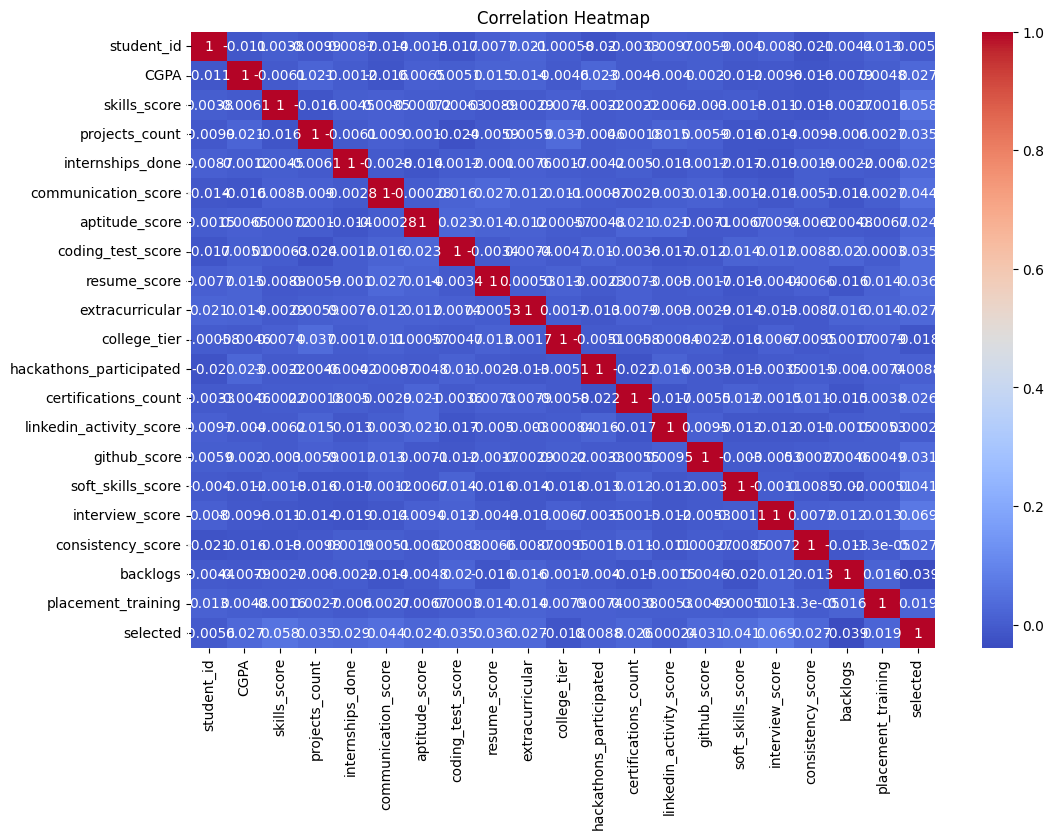

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

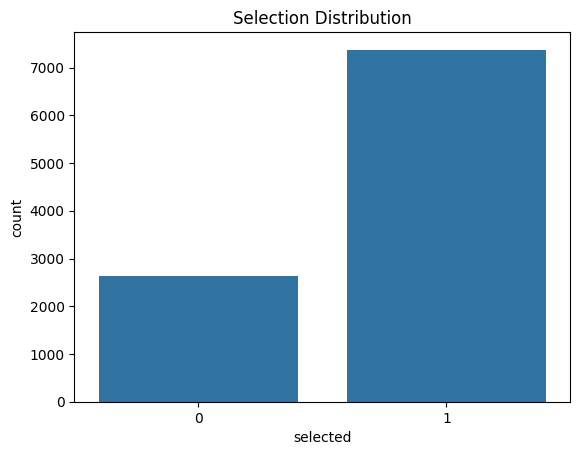

In [25]:
sns.countplot(x=y)
plt.title("Selection Distribution")
plt.show()

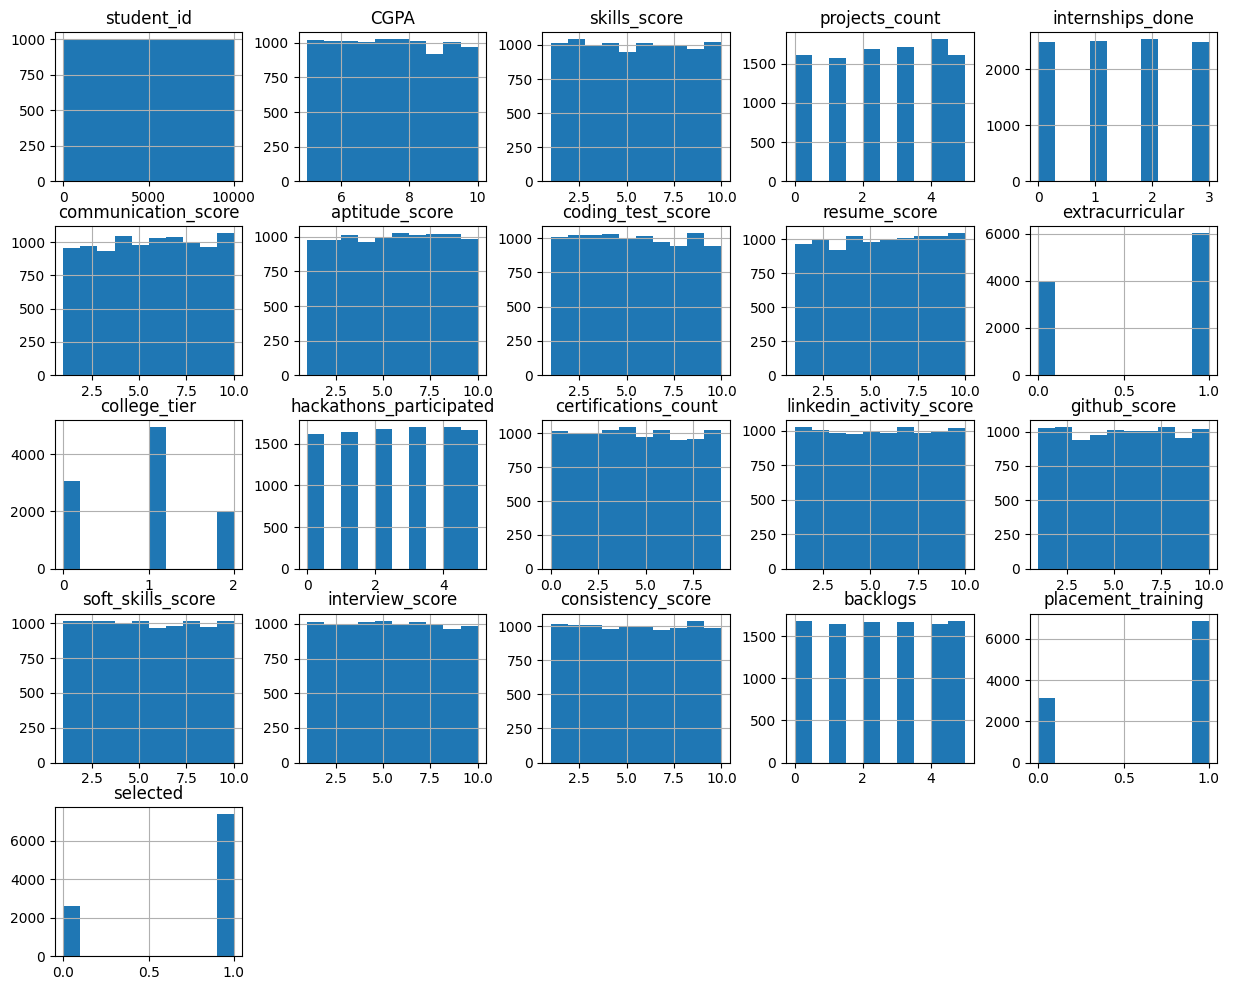

In [26]:
df.hist(figsize=(15,12))
plt.show()

In [28]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       470
           1       0.77      1.00      0.87      1530

    accuracy                           0.77      2000
   macro avg       0.38      0.50      0.43      2000
weighted avg       0.59      0.77      0.66      2000



C:\Users\ADHITHYA\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADHITHYA\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADHITHYA\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

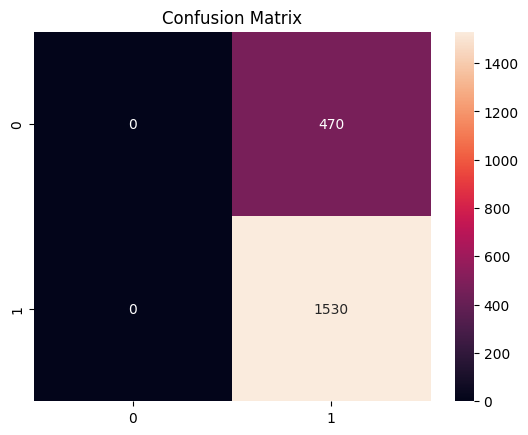

In [29]:
cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [30]:
pickle.dump(svm_model, open("svm_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("\nModel Saved Successfully")


Model Saved Successfully
